# Applying Fitts' law to Wikispeedia

In [1]:
from DataLoader import DataLoader
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, SimilarityFunction
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy import stats

tqdm.pandas()

/home/floris/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataloader = DataLoader("data")
dataloader.load_paths("paths_finished.tsv")
dataloader.load_edges("links.tsv")
dataloader.paths

,hashedIpAddress,timestamp,durationInSec,path,rating,Goal
0,3824310e536af032,1344753412,88,"[14th_century, Europe, Africa, Atlantic_slave_...",3.0,African_slave_trade
1,415612e93584d30e,1349298640,138,"[14th_century, Niger, Nigeria, British_Empire,...",NaN,African_slave_trade
2,64dd5cd342e3780c,1265613925,37,"[14th_century, Renaissance, Ancient_Greece, Gr...",NaN,Greece
3,015245d773376aab,1366730828,175,"[14th_century, Italy, Roman_Catholic_Church, H...",3.0,John_F._Kennedy
4,5295bca242be81fe,1372890414,110,"[14th_century, Europe, North_America, United_S...",NaN,John_F._Kennedy
...,...,...,...,...,...,...
51312,15a13a1d66ef5456,1349231015,66,"[Yagan, Ancient_Egypt, Civilization]",NaN,Civilization
51313,2ef7ac844cefda58,1300254138,165,"[Yagan, Folklore, Brothers_Grimm, Folklore, 19...",3.0,Fiction
51314,12863abb7887f890,1385095372,228,"[Yagan, Australia, England, France, United_Sta...",NaN,U.S._Open_%28tennis%29
51315,19f8284371753362,1298792567,56,"[Yarralumla%2C_Australian_Capital_Territory, A...",1.0,Abraham_Lincoln


In [3]:
dataloader.paths.sort_values(by="durationInSec")[:50000]

,hashedIpAddress,timestamp,durationInSec,path,rating,Goal
30760,43f864c75b2571b5,1350587420,0,[Royal_Navy],NaN,Royal_Navy
9871,43f864c75b2571b5,1350587395,0,[Coal],NaN,Coal
9588,5590014e126275b4,1225696755,0,[Moon],NaN,Moon
20918,43f864c75b2571b5,1350587389,0,[Pyramid],NaN,Pyramid
24325,43f864c75b2571b5,1350587377,0,[Snow_Goose],NaN,Snow_Goose
...,...,...,...,...,...,...
20287,038fa48f0d6caadf,1301670739,555,"[Pyramid, France, Portuguese_language, Brazil,...",4.0,Bean
1532,581af58d2fafd5d5,1353011517,555,"[Batman, Scotland, Ireland, United_Kingdom, Wo...",NaN,The_Holocaust
10289,2ad31bd915588ac8,1345103988,555,"[Persian_Gulf, United_Nations, Cold_War, Unite...",3.0,Hundred_Years%27_War
47827,18f04531320cff22,1255905866,555,"[Tank, World_War_II, United_Kingdom, Market, M...",5.0,Asparagus


## Embed article titles as distance metric

In [4]:
model = SentenceTransformer("all-MiniLM-L6-v2")
model.similarity_fn_name = SimilarityFunction.EUCLIDEAN

In [5]:
articles = pd.read_csv('data/articles.tsv', sep='\t')

In [6]:
embeddings_array = model.encode(articles['article'], show_progress_bar=True)
embeddings = {}
for i, article in enumerate(articles['article']):
    embeddings[article] = embeddings_array[i]

Batches:   0%|          | 0/144 [00:00<?, ?it/s]

Batches: 100%|██████████| 144/144 [00:08<00:00, 16.41it/s]


## Load optimal paths

In [7]:
llm_optimal = { k : g.distance.to_dict() for k,g in pd.read_csv("pairs_llm_distances.csv").set_index("source").groupby("target") }

In [8]:
click_optimal = { k : g.distance.to_dict() for k,g in pd.read_csv("pairs_click_distances.csv").set_index("source").groupby("target") }

# Analyze paths

In [ ]:
import networkx as nx

edges = pd.read_csv('data/links.tsv', sep='\t', names=['source', 'target'])
edges["distance"] = edges.progress_apply(lambda row: -float(model.similarity(embeddings[row['source']], embeddings[row['target']])[0,0]), axis=1)
edges

G = nx.from_pandas_edgelist(edges, 'source', 'target', edge_attr='distance', create_using=nx.DiGraph())

100%|██████████| 119882/119882 [00:11<00:00, 10797.58it/s]


[0,
 27,
 13,
 14,
 180,
 319,
 49,
 87,
 26,
 20,
 338,
 168,
 0,
 306,
 57,
 31,
 291,
 97,
 248,
 155,
 60,
 246,
 27,
 60,
 35,
 520,
 43,
 293,
 351,
 147,
 972,
 751,
 0,
 6,
 50,
 12,
 9,
 19,
 959,
 7,
 743,
 23,
 550,
 13,
 342,
 40,
 308,
 40,
 28,
 122,
 182,
 171,
 0,
 571,
 598,
 23,
 84,
 31,
 128,
 0,
 10,
 751,
 60,
 20,
 78,
 35,
 0,
 85,
 250,
 232,
 230,
 138,
 66,
 1,
 65,
 68,
 47,
 45,
 26,
 45,
 246,
 39,
 17,
 42,
 75,
 86,
 73,
 14,
 52,
 71,
 7,
 17,
 50,
 324,
 60,
 33,
 3,
 342,
 539,
 31,
 23,
 331,
 1551,
 67,
 59,
 43,
 65,
 57,
 72,
 101,
 76,
 131,
 25,
 68,
 7,
 611,
 18,
 32,
 274,
 104,
 173,
 288,
 99,
 45,
 85,
 84,
 71,
 100,
 125,
 127,
 172,
 286,
 46,
 36,
 34,
 31,
 32,
 48,
 54,
 44,
 63,
 52,
 15,
 18,
 496,
 37,
 20,
 10,
 25,
 18,
 85,
 86,
 3,
 8,
 68,
 106,
 8,
 410,
 77,
 31,
 5,
 93,
 9,
 10,
 25,
 32,
 172,
 131,
 223,
 27,
 19,
 17,
 9,
 85,
 9,
 14,
 80,
 197,
 357,
 29,
 144,
 85,
 40,
 933,
 97,
 295,
 23,
 65,
 30,
 146,
 21,
 21

(array([457., 442., 308., 281., 200., 173., 160., 172., 126., 121., 107.,
         87.,  83.,  86.,  69.,  82.,  68.,  65.,  58.,  51.,  66.,  40.,
         37.,  47.,  37.,  40.,  34.,  32.,  24.,  28.,  27.,  23.,  29.,
         18.,  25.,  19.,  15.,  28.,  20.,  23.,  13.,  17.,  20.,  28.,
         14.,  16.,  13.,  13.,  20.,  12.,  15.,   8.,  11.,  14.,  19.,
         10.,  11.,  10.,   9.,  16.,  13.,   9.,  13.,  13.,   7.,  14.,
          8.,   6.,   9.,   7.,   5.,   7.,  14.,   6.,   5.,   6.,  13.,
          9.,   3.,   8.,   6.,   6.,   3.,   4.,   8.,  11.,   6.,   6.,
          2.,   5.,   4.,   2.,   1.,   4.,   3.,   3.,   1.,   8.,   3.,
          7.]),
 array([ 0.  ,  0.99,  1.98,  2.97,  3.96,  4.95,  5.94,  6.93,  7.92,
         8.91,  9.9 , 10.89, 11.88, 12.87, 13.86, 14.85, 15.84, 16.83,
        17.82, 18.81, 19.8 , 20.79, 21.78, 22.77, 23.76, 24.75, 25.74,
        26.73, 27.72, 28.71, 29.7 , 30.69, 31.68, 32.67, 33.66, 34.65,
        35.64, 36.63, 37.62, 38.61

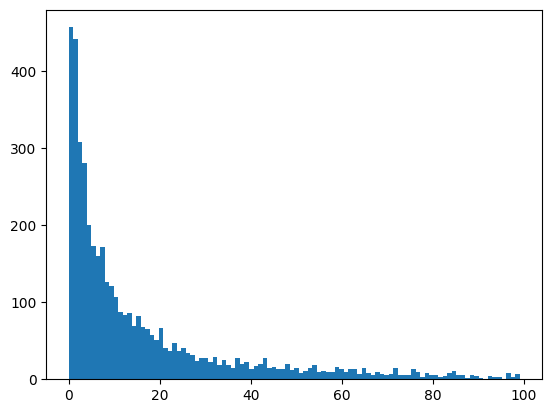

In [108]:
no_in = [G.in_degree(node) for node in G.nodes if G.in_degree(node) < 100]
plt.hist(no_in, bins=100)

In [132]:
def analyze_path(p):
    try:
        path = p['path']
        length = len(path) - 1
        if length < 2:
            # ignore non-games and direct games
            return None
        target_pagerank = dataloader.pagerank[path[-1]] # use pagerank as size
        in_degree = G.in_degree(path[-1])

        llm_distance = -float(model.similarity(embeddings[path[0]], embeddings[path[-1]]))
        # distance = llm_optimal[path[0]][path[-1]]
        llm_opt_distance = llm_optimal[path[-1]][path[0]]
        opt_distance = click_optimal[path[-1]][path[0]]


        llm_difficulty = math.log2(llm_distance / target_pagerank + 1)
        llm_difficulty_in_degree = math.log2(llm_distance / in_degree + 1)
        
        llm_opt_difficulty = math.log2(llm_opt_distance / target_pagerank + 1)
        llm_opt_difficulty_in_degree = math.log2(llm_opt_distance / in_degree + 1)

        opt_difficulty = math.log2(opt_distance / target_pagerank + 1)
        opt_difficulty_in_degree = math.log2(opt_distance / in_degree + 1)

        time = p['durationInSec']
        if time > 600:
            # ignore outliers
            return None
        return pd.Series([path[0], path[-1], 1, time, \
                          llm_difficulty, llm_difficulty_in_degree, \
                          llm_opt_difficulty, llm_opt_difficulty_in_degree, \
                          opt_difficulty, opt_difficulty_in_degree, llm_distance, llm_opt_distance, opt_distance, target_pagerank, in_degree, length])
    except KeyError:
        return None


df = dataloader.paths.progress_apply(analyze_path, axis=1).dropna()
df.columns = ["Source", "Target", "Count", "Time", "LLMDifficulty", "LLMDifficultyIndegree", "LLMOptDifficulty", "LLMOptDifficultyIndegree", "OptDifficulty", "OptDifficultyIndegree", "LLMDistance", "LLMOptDistance", "OptDistance", "PageRank", "InDegree", "Length"]
df

100%|██████████| 51317/51317 [00:11<00:00, 4318.31it/s]


,Source,Target,Count,Time,LLMDifficulty,LLMDifficultyIndegree,LLMOptDifficulty,LLMOptDifficultyIndegree,OptDifficulty,OptDifficultyIndegree,LLMDistance,LLMOptDistance,OptDistance,PageRank,InDegree,Length
0,14th_century,African_slave_trade,1.0,88.0,14.796805,0.223957,16.254458,0.547209,16.148426,0.514573,1.175529,3.228794,3.0,0.000041,7.0,4.0
1,14th_century,African_slave_trade,1.0,138.0,14.796805,0.223957,16.254458,0.547209,16.148426,0.514573,1.175529,3.228794,3.0,0.000041,7.0,7.0
2,14th_century,Greece,1.0,37.0,9.415394,0.006639,10.169291,0.011185,10.232228,0.011682,1.134654,1.914556,2.0,0.001664,246.0,3.0
3,14th_century,John_F._Kennedy,1.0,175.0,11.872514,0.028858,13.264927,0.074573,13.179536,0.070389,1.212270,3.182947,3.0,0.000323,60.0,6.0
4,14th_century,John_F._Kennedy,1.0,110.0,11.872514,0.028858,13.264927,0.074573,13.179536,0.070389,1.212270,3.182947,3.0,0.000323,60.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51312,Yagan,Civilization,1.0,66.0,11.091372,0.030795,11.957510,0.055661,11.767625,0.048910,1.251362,2.281426,2.0,0.000574,58.0,2.0
51313,Yagan,Fiction,1.0,165.0,12.775581,0.056661,14.039505,0.132514,14.048059,0.133267,1.241741,2.982265,3.0,0.000177,31.0,8.0
51314,Yagan,U.S._Open_%28tennis%29,1.0,228.0,13.075030,0.106081,14.409333,0.253879,14.284593,0.234465,1.297113,3.270948,3.0,0.000150,17.0,6.0
51315,Yarralumla%2C_Australian_Capital_Territory,Abraham_Lincoln,1.0,56.0,11.656839,0.030542,12.439225,0.052144,12.249025,0.045804,1.326535,2.281901,2.0,0.000411,62.0,3.0


## Take means of path times and filter by number of occurences

In [133]:
df_mean = df.groupby(["Source", "Target"]).agg({
    "Count": "sum",
    "Time": "mean",
    "LLMDifficulty": "mean",
    "LLMDifficultyIndegree": "mean",
    "LLMOptDifficulty": "mean",
    "LLMOptDifficultyIndegree": "mean",
    "OptDifficulty": "mean",
    "OptDifficultyIndegree": "mean",
    "Length": "mean"
})

df_mean_filtered = df_mean[df_mean["Count"] >= 3]

In [134]:
df_mean_filtered

Count        Time  LLMDifficulty  \
Source        Target                                                         
11th_century  Taiwan                        3.0   68.000000      10.717516   
12th_century  Guitar                        4.0  119.000000      12.113336   
              Zimbabwe                      5.0  188.600000      11.341342   
14th_century  Elizabeth_I_of_England        5.0  147.000000      11.505735   
              Rainbow                      27.0  181.925926      13.136624   
...                                         ...         ...            ...   
Zeus          North_Korea                   5.0  120.800000      10.918712   
Zinc          American_Revolutionary_War    3.0  136.000000      11.867389   
Zinc_chloride Age_of_Enlightenment          3.0  180.666667      11.143142   
Zulu          Aluminium                     3.0   97.666667      10.645170   
              Arctic_Circle                 3.0  100.666667      12.433199   

                                          LLMDifficultyIndegree  \
Source        Target                                              
11th_century  Taiwan                                   0.019005   
12th_century  Guitar                                   0.033698   
              Zimbabwe                                 0.019700   
14th_century  Elizabeth_I_of_England                   0.025731   
              Rainbow                                  0.162481   
...                                                         ...   
Zeus          North_Korea                              0.023366   
Zinc          American_Revolutionary_War               0.038033   
Zinc_chloride Age_of_Enlightenment                     0.031738   
Zulu          Aluminium                                0.015998   
              Arctic_Circle                            0.088462   

                                          LLMOptDifficulty  \
Source        Target                                         
11th_century  Taiwan                             11.377865   
12th_century  Guitar                             13.421164   
              Zimbabwe                           12.489214   
14th_century  Elizabeth_I_of_England             12.274298   
              Rainbow                            14.248660   
...                                                    ...   
Zeus          North_Korea                        12.229966   
Zinc          American_Revolutionary_War         13.121735   
Zinc_chloride Age_of_Enlightenment               12.333842   
Zulu          Aluminium                          12.022535   
              Arctic_Circle                      13.790782   

                                          LLMOptDifficultyIndegree  \
Source        Target                                                 
11th_century  Taiwan                                      0.029929   
12th_century  Guitar                                      0.082041   
              Zimbabwe                                    0.043305   
14th_century  Elizabeth_I_of_England                      0.043569   
              Rainbow                                     0.330775   
...                                                            ...   
Zeus          North_Korea                                 0.057321   
Zinc          American_Revolutionary_War                  0.089140   
Zinc_chloride Age_of_Enlightenment                        0.071466   
Zulu          Aluminium                                   0.041214   
              Arctic_Circle                               0.216690   

                                          OptDifficulty  \
Source        Target                                      
11th_century  Taiwan                          11.414778   
12th_century  Guitar                          13.346308   
              Zimbabwe                        12.684276   
14th_century  Elizabeth_I_of_England          12.324489   
              Rainbow                         14.330485   
...                     

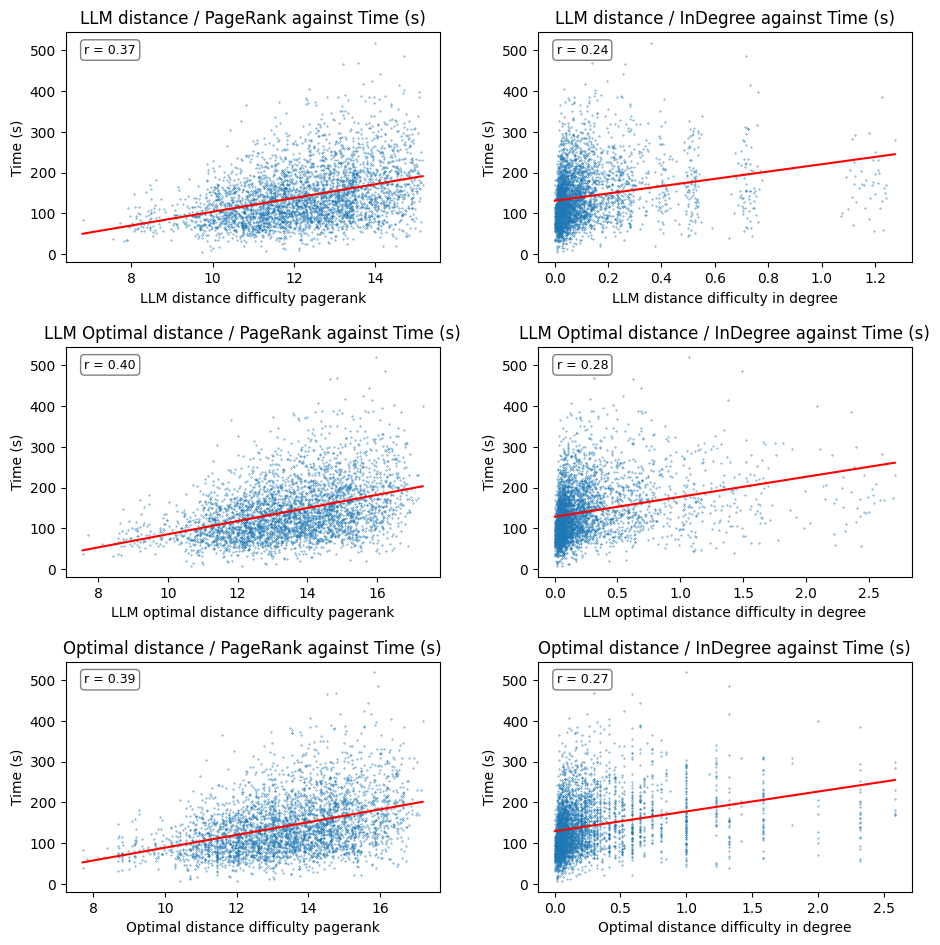

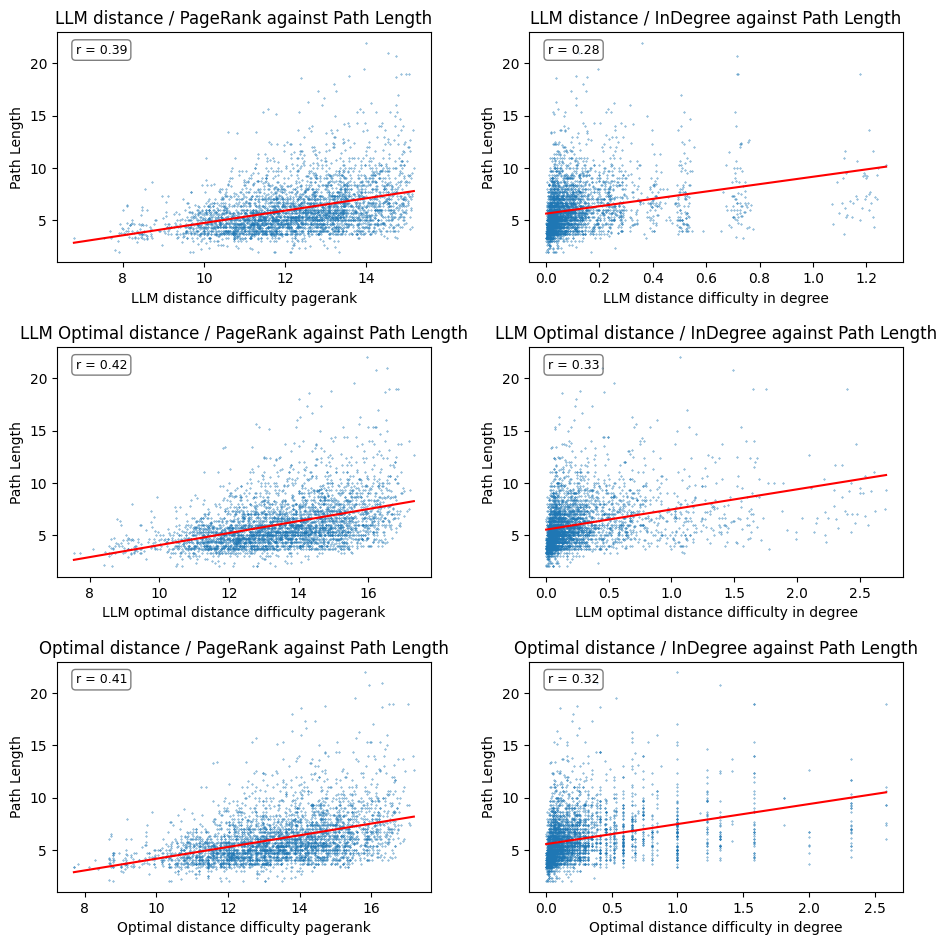

In [ ]:
import matplotlib.pyplot as plt

IDs = ["LLMDifficulty", "LLMDifficultyIndegree", "LLMOptDifficulty", "LLMOptDifficultyIndegree", "OptDifficulty", "OptDifficultyIndegree"]
x_labels = ["LLM distance difficulty pagerank", "LLM distance difficulty in degree", "LLM optimal distance difficulty pagerank", "LLM optimal distance difficulty in degree", "Optimal distance difficulty pagerank", "Optimal distance difficulty in degree"]


preds = ["Time", "Length"]
y_labels = ["Time (s)", "Path Length"]

titles1 = ["LLM distance / PageRank against", "LLM distance / InDegree against",
          "LLM Optimal distance / PageRank against", "LLM Optimal distance / InDegree against",
          "Optimal distance / PageRank against", "Optimal distance / InDegree against"]

final_titles = [f"{titles1[i]} {y_labels[0]}" for i in range(6)] + [f"{titles1[i]} {y_labels[1]}" for i in range(6)]

for z in range(2):
    fig, axs = plt.subplots(3, 2, figsize=(10, 10))
    plt.tight_layout(pad=4.0)  # adds padding between subplots and labels

    for i in range(3):
        for j in range(2):
            X = df_mean_filtered[IDs[2*i + j]]
            y = df_mean_filtered[preds[z]]

            slope, intercept, rval, pval, stderr = stats.linregress(X, y)
            axs[i, j].scatter(X, y, s=0.1)
            xs = np.linspace(min(X), max(X))
            ys = slope*xs + intercept

            axs[i, j].text(
                0.05, 0.95,                      # x, y position in axes coordinates
                f"r = {rval:.2f}",               # formatted r-value
                transform=axs[i, j].transAxes,   # interpret coordinates relative to the axes
                fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.5)
            )

            axs[i, j].plot(xs, ys, color="red")
            axs[i, j].set_title(final_titles[6 * z + 2*i + j])
            axs[i, j].set_xlabel(x_labels[2*i + j])

    for ax in axs.flat:
        ax.set(ylabel=f'{y_labels[z]}')
